In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'

def linear_prediction(
        signal: pd.Series,
        p: int,
        T_ex: int,
        rcond: float = 1e-10,
    ) -> pd.Series:
    """
    Extrapolate a 1D complex/real time series using Linear Prediction (LP).

    Parameters
    ----------
    signal : pd.Series
        Input time series (index = time axis, values = signal amplitudes).
        May be real or complex-valued. Length must be > p.
    p : int
        Prediction order (number of past samples used per step).
        A common heuristic is p ~ N/3 to N/2, where N = len(signal).
    T_ex : int
        Number of additional time steps to extrapolate beyond the end of
        the input signal.
    rcond : float, optional
        Relative cut-off for small singular values in the SVD solver.
        Singular values smaller than rcond * sigma_max are discarded to
        regularise the solution. Default is 1e-10.

    Returns
    -------
    pd.Series
        Extended time series of length len(signal) + T_ex.
        The index is extrapolated uniformly using the same time step
        inferred from the original index.
        The original signal is preserved exactly in the first len(signal)
        entries; only the appended T_ex values are LP-predicted.

    Raises
    ------
    ValueError
        If p >= len(signal) or T_ex < 1.

    Notes
    -----
    * The extrapolated signal can become unstable (growing exponentially)
      if LP roots lie outside the unit circle. Inspect the roots with the
      companion utility `lp_roots` below if instability is suspected.

    """
    
    # ------------------------------------------------------------------ #
    # 0. Validate inputs                                                   #
    # ------------------------------------------------------------------ #
    N = len(signal)
    if p >= N:
        raise ValueError(
            f"Prediction order p={p} must be strictly less than "
            f"the signal length N={N}."
        )
    if T_ex < 1:
        raise ValueError(f"T_ex must be a positive integer, got {T_ex}.")

    c = signal.to_numpy(dtype=complex if np.iscomplexobj(signal.values) else float)

    # ------------------------------------------------------------------ 
    # 1. Build the Hankel data matrix and RHS vector                     
    #                                                                    
    #   H[i, k] = c[p + i - 1 - k],  i = 0..N-p-1,  k = 0..p-1         
    #   rhs[i]  = c[p + i]                                             
    # ------------------------------------------------------------------ 
    n_rows = N - p                          # number of equations
    
    # Each row i: [c[p+i-1], c[p+i-2], ..., c[i]]
    row_indices = np.arange(p, N)           # shape (n_rows,)
    col_offsets = np.arange(p)              # shape (p,)
    H = c[row_indices[:, None] - 1 - col_offsets[None, :]]  # (n_rows, p)
    rhs = c[p:]                             # (n_rows,)

    # ------------------------------------------------------------------ 
    # 2. Solve for LP coefficients via SVD least-squares               
    # ------------------------------------------------------------------ 
    # Equivalent to: a = argmin ||H @ a - rhs||^2
    
    U, s, Vh = np.linalg.svd(H, full_matrices=False)
    # Regularised pseudo-inverse: discard singular values below threshold
    threshold = rcond * s[0]
    s_inv = np.where(s > threshold, 1.0 / s, 0.0)
    
    # a = H^-1 rhs = V @ diag(s_inv) @ Uh @ rhs
    a = (Vh.conj().T * s_inv) @ (U.conj().T @ rhs)  # shape (p,)

    # ------------------------------------------------------------------ 
    # 3. Extrapolate T_ex steps                                          
    # ------------------------------------------------------------------ 
    # Keep a rolling buffer of the last p values for efficiency
    buffer = list(c[-p:])                   # most-recent p values
    predicted = []

    for _ in range(T_ex):
        # c_new = a[0]*buf[-1] + a[1]*buf[-2] + ... + a[p-1]*buf[-p]
        c_new = np.dot(a, buffer[::-1]) # inverse order
        predicted.append(c_new)
        buffer.append(c_new)
        buffer.pop(0)

    # ------------------------------------------------------------------ #
    # 4. Assemble output Series with extrapolated index                   #
    # ------------------------------------------------------------------ #
    original_index = signal.index.to_numpy()

    # Infer uniform time step from the original index
    if len(original_index) >= 2:
        dt = (original_index[-1] - original_index[0]) / (len(original_index) - 1)
    else:
        dt = 1.0

    extra_index = original_index[-1] + dt * np.arange(1, T_ex + 1)
    extended_index = np.concatenate([original_index, extra_index])

    # Preserve original dtype (real signal → real output)
    extended_values = np.concatenate([c, predicted])
    if not np.iscomplexobj(signal.values):
        extended_values = extended_values.real

    return pd.Series(extended_values, index=extended_index, name=signal.name)

def lp_roots(a: np.ndarray, dt: float = 1.0):
    """
    Compute the poles (roots of the LP characteristic polynomial) and
    decode their physical frequencies and damping rates.

    The characteristic polynomial is:
        z^p - a[0]*z^{p-1} - a[1]*z^{p-2} - ... - a[p-1] = 0

    Each root z_m encodes:
        omega_m = -Im(log z_m) / dt      [angular frequency]
        gamma_m = -Re(log z_m) / dt      [damping rate; >0 → decaying]

    Parameters
    ----------
    a : np.ndarray, shape (p,)
        LP coefficients returned by the internal solver (not exposed
        directly by `linear_prediction`; use this for diagnostics by
        calling the SVD block manually or monkey-patching).
    dt : float
        Time step of the original signal.

    Returns
    -------
    dict with keys:
        'roots'  : complex ndarray, shape (p,)
        'omega'  : real ndarray — angular frequencies
        'gamma'  : real ndarray — damping rates
        'stable' : bool ndarray — True if |z_m| <= 1 (non-growing mode)
    """
    # Characteristic polynomial coefficients: [1, -a[0], -a[1], ..., -a[p-1]]
    poly = np.concatenate([[1.0], -a])
    roots = np.roots(poly)
    log_roots = np.log(roots + 0j)
    omega = -log_roots.imag / dt
    gamma = -log_roots.real / dt
    stable = np.abs(roots) <= 1.0
    return {"roots": roots, "omega": omega, "gamma": gamma, "stable": stable}
    
def read_data(fname, p, T_ex, col=0, cut=-1):
    
    dmrg = pd.read_csv(fname)
    
    Time = np.array(dmrg.t)
    if (isinstance(col, int)) and (col == 0):
        chi_re, chi_im = np.zeros(len(Time)), np.zeros(len(Time))
        for m in range(2*N):
            chi_re += dmrg[f"RS{m+1}"]
            chi_im += dmrg[f"IS{m+1}"]
    elif (isinstance(col, int)) and (col==-1):
        chi_re = dmrg[f"RS"]
        chi_im = dmrg[f"IS"]
    elif (isinstance(col, int)):
        chi_re = dmrg[f"RS{col}"]
        chi_im = dmrg[f"IS{col}"]
    elif (isinstance(col, list)):
        chi_re, chi_im = np.zeros(len(Time)), np.zeros(len(Time))
        for i in col:
            chi_re += dmrg[f"RS{i}"]
            chi_im += dmrg[f"IS{i}"]
    elif (isinstance(col, str)) and (col == 'c'):
        chi_re, chi_im = np.zeros(len(Time)), np.zeros(len(Time))
        chi_re += dmrg[f"RS{N}"]
        chi_im += dmrg[f"IS{N}"]
        chi_re += dmrg[f"RS{N-1}"]
        chi_im += dmrg[f"IS{N-1}"]
    else:
        print("Invalid request!")
        return 0
        
    if cut>0:
        Time = Time[:cut]
        chi_re = chi_re[:cut]
        chi_im = chi_im[:cut]
    
    if p > 0:
        Time = Time
        chi_re_ext = linear_prediction(chi_re, p, T_ex)
        chi_im_ext = linear_prediction(chi_im, p, T_ex)
        dt = Time[1] - Time[0]
        Time_ext = np.concatenate([Time, Time[-1] + dt * np.arange(1, len(chi_re_ext)-len(Time)+1)])
        
        return Time_ext, chi_re_ext, chi_im_ext
    else:
        return Time, chi_re, chi_im

def DMRGplots(
    Time, chi_re, chi_im, p1, p2, beta, 
    sigma=0, bc="PBC", operators="+-", Q="K-", h=0.1, dmrgT=0, nomega=200):

    w = np.linspace(0, 6, nomega)

    gaussian = lambda x, sigma: np.exp(-(x/sigma)**2/2)

    dt = Time[1]-Time[0]
    sqT = 1/np.sqrt(2*Time[-1])
    if sigma > 0:
        Amp = gaussian(Time, sigma)
    else:
        Amp = np.ones(len(Time))

    S = []
    for idx, omega in enumerate(w):
        int_sum = 0
        for i in range(len(Time)):
            int_sum += sqT * 2*np.cos(omega * Time[i]) * chi_re[i] * Amp[i]
            int_sum -= sqT * 2*np.sin(omega * Time[i]) * chi_im[i] * Amp[i]
        S.append(int_sum*dt)
        
    
    fig, axs = plt.subplots(2, 1, figsize=(6, 8), dpi=200)
    # fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

    ax = axs[0]
    ax.plot(w, S, lw=3, c="#CC0FD690",
        label=f"$\\lambda =200$ \n$\\sigma = {sigma}$"
        )
    # p1, p2 = 1.55, 2.55
    y1, y2 = min(min(S)*1.5, 0), max(S)*1.1
    # y1, y2 = -0.05, 0.07
    ax.plot([p1, p1], [y1, y2], label=f'$\\omega=${p1}', ls='-.')
    ax.plot([p2, p2], [y1, y2], label=f'$\\omega=${p2} \nGap = {round(p2-p1, 3)}', ls='-.')

    ax.legend(fontsize=15, loc='upper right')
    ax.set_xlabel("$\\omega/J$", fontsize=15)
    ax.set_ylabel(f"$S^{{{operators}}}({Q}, \\omega)$", fontsize=15)
    ax.set_xlim(0, 5)
    ax.set_ylim(y1, y2)
    ax.tick_params(axis='both', labelsize=12)

    if beta>0:
        temp = round(1/beta, 3)
        ax.set_title(f"{N}x{M} {bc}. J\'={nnn} DM={DM} Temp: {temp} ", fontsize=14)
    else:
        temp = 0
        ax.set_title(f"{N}x{M} {bc}. J\'={nnn} DM={DM} h={h} T=0.", fontsize=14)

    ax = axs[1]
    ax.scatter(Time, chi_re,
        s=30, marker="o", c="#FC0FA690", edgecolors='none',
        label=f"Real."
        )
    ax.scatter(Time, chi_im,
        s=30, marker="s", c="#AC0FF640", edgecolors='none',
        label=f"imaginary."
        )
    ax.plot(Time, chi_re*Amp,
        marker=".", c="k", lw=1, markersize=3,
        label=f"Re$\\chi$ * G(t)."
        )
    if dmrgT > 0:
        ax.plot([dmrgT, dmrgT], [max(chi_re), min(chi_re)], 
            label='TDVP$\\leftrightarrow$LP')
        
    ax.legend(fontsize=12, loc='upper right')
    ax.set_xlabel("Time [s]", fontsize=15)
    ax.set_ylabel(f"$S^{{{operators}}}(t)$", fontsize=15)
    T = Time[-1]
    # T = 5
    ax.set_xlim(0, T)
    ax.tick_params(axis='both', labelsize=12)

    plt.show()
    
    return np.array(S)


def Lorentz(x, A, c, gamma):
    return A * gamma/((x-c)**2 + gamma**2)

def Two_Lorentz(x, A1, A2, c1, c2, gamma1, gamma2):
    return Lorentz(x, A1, c1, gamma1) + Lorentz(x, A2, c2, gamma2)

def Tri_Lorentz(x, A1, A2, A3, c1, c2, c3, gamma1, gamma2, gamma3):
    return Lorentz(x, A1, c1, gamma1) + Lorentz(x, A2, c2, gamma2) + Lorentz(x, A3, c3, gamma3)

def fitplot(S, p, Amp, beta, bc="PBC", Q="K+", h=0.1, nomega=200, w=[0.1, 0.1], force=False):
    
    omega = np.linspace(0, 6, nomega)
    
    if force: 
        A1, A2, c1, c2, gamma1, gamma2 = Amp[0], Amp[1], p[0], p[1], w[0], w[1]
    else:
        popt, pcov = curve_fit(Two_Lorentz, omega, S, p0=[Amp[0], Amp[1], p[0], p[1], w[0], w[1]])
        A1, A2, c1, c2, gamma1, gamma2 = popt
    print(f'(a1, a2)=({round(A1, 4)}, {round(A2, 4)})')
    print(f'(c1, c2)=({round(c1, 2)}, {round(c2, 2)})')
    print(f'Gamma=({round(gamma1, 3)}, {round(gamma2, 3)})')
    
    fig, ax = plt.subplots()
    
    ax.plot(omega, S, lw=4, c="#CC0FD690",
        label=f"DMRG\n$\\sigma =${sigma}", zorder=10
        )
    
    ax.plot(omega, Lorentz(omega, A1, c1, gamma1), lw=2, c='C0', alpha=0.7,
        label=f'Fit 1\n$\\omega_1 = {round(c1, 2)}$')
    ax.plot(omega, Lorentz(omega, A2, c2, gamma2), lw=2, c='C1', alpha=0.7,
        label=f'Fit 2\n$\\omega_2 = {round(c2, 2)}$')
    ax.plot(omega, Two_Lorentz(omega, A1, A2, c1, c2, gamma1, gamma2), 
        lw=1, c='k', ls=':',
        label='All')
    
    y1, y2 = min(min(S)*1.1, 0), max(S)*1.2
    
    ax.legend(fontsize=12, loc='upper right')
    ax.set_xlabel("$\\omega$ [J]", fontsize=18)
    ax.set_ylabel(f"$S(\\omega, {Q})$", fontsize=18)
    ax.set_xlim(0, 5)
    ax.set_ylim(y1, y2)
    ax.tick_params(axis='both', labelsize=15)
    
    if beta>0:
        temp = round(1/beta, 3)
        ax.set_title(f"$S^{{+-}}$ {N}x{M} {bc}. DM={DM} Temp: {temp} Gap={round(c1-c2, 2)}", fontsize=14)
    else:
        temp = 0
        ax.set_title(f"$S^{{+-}}$ {N}x{M} {bc}. DM={DM} h={h} T=0. Gap={round(c1-c2, 2)}", fontsize=14)
        
    plt.show()

def fitplot3(S, p, Amp, beta, bc="PBC", Q="K+", h=0.1, nomega=200, w=[0.5, 0.5, 0.5]):
    
    omega = np.linspace(0, 6, nomega)
    
    popt, pcov = curve_fit(Tri_Lorentz, omega, S, 
        p0=[Amp[0], Amp[1], Amp[2], p[0], p[1], p[2], w[0], w[1], w[2]])
    A1, A2, A3, c1, c2, c3, gamma1, gamma2, gamma3 = popt
    print(f'(a1, a2, a3)=({round(A1, 4)}, {round(A2, 4)}, {round(A3, 4)})')
    print(f'(c1, c2, c3)=({round(c1, 2)}, {round(c2, 2)}, {round(c3, 2)})')
    print(f'Gamma=({round(gamma1, 3)}, {round(gamma2, 3)}, {round(gamma2, 3)})')
    
    fig, ax = plt.subplots()
    
    ax.plot(omega, S, lw=4, c="#CC0FD690",
        label=f"DMRG\n$\\sigma =${sigma}", zorder=10
        )
    
    ax.plot(omega, Lorentz(omega, A1, c1, gamma1), lw=2, c='C0', alpha=0.7,
        label=f'Fit 1\n$\\omega_1 = {round(c1, 2)}$')
    ax.plot(omega, Lorentz(omega, A2, c2, gamma2), lw=2, c='C1', alpha=0.7,
        label=f'Fit 2\n$\\omega_2 = {round(c2, 2)}$')
    ax.plot(omega, Lorentz(omega, A3, c3, gamma3), lw=2, c='C3', alpha=0.7,
        label=f'Fit 3\n$\\omega_3 = {round(c3, 2)}$')
    ax.plot(omega, Tri_Lorentz(omega, A1, A2, A3, c1, c2, c3, gamma1, gamma2, gamma3), 
        lw=1, c='k', ls=':',
        label='All')
    
    y1, y2 = min(min(S)*1.1, 0), max(S)*1.2
    
    ax.legend(fontsize=13, loc='upper right')
    ax.set_xlabel("$\\omega$ [J]", fontsize=18)
    ax.set_ylabel(f"$S(\\omega, {Q})$", fontsize=18)
    ax.set_xlim(0, 5)
    ax.set_ylim(y1, y2)
    ax.tick_params(axis='both', labelsize=15)
    
    if beta>0:
        temp = round(1/beta, 3)
        ax.set_title(f"$S^{{+-}}$ {N}x{M} {bc}. DM={DM} Temp: {temp} Gap={round(c1-c2, 2)}", fontsize=14)
    else:
        temp = 0
        ax.set_title(f"$S^{{+-}}$ {N}x{M} {bc}. DM={DM} h={h} T=0. Gap={round(c1-c2, 2)}", fontsize=14)
        
    plt.show()


# Correlation spread

In [3]:
size = '2412'
operators = '+-'
K = 'K^-'
# K = '\\Gamma'
# beta = '2.50'

# files = sorted(glob.glob(f"../HC_data/v5/Chi_{size}_*_DM0.10_h0.1*_Oxt_Oyf_AB*_*_*1.0*K-_GS*+-_gauged_*.csv"))
# titles = [f'{size}. EdgeB. {K}', f'{size}. Bulk. {K}', f'{size}. EdgeA. {K}']
# files = glob.glob(f"../HC_data/Chi_{size}*beta{beta}/Chi_{size}_*1.00K*_{operators}_real.csv")
files = glob.glob(f"../HC_data/Chi_{size}*_T0/Chi*1.00K*_{operators}_real*.csv")

# title = f'{size}. DMI=0.1. h=1.0 {K}. Center=A+B. Beta inf. dtau0.02 mindim7'
# title = f'{size}. DMI=0.1 h=0.1 : Real : $\\beta=${beta}'
title = f'{size}. DMI=0.1 h=0.1 : Real : T$=0.0$'
T_max = -1
T_max = int(T_max)

data = pd.read_csv(files[0])

files

['../HC_data/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB1213_T0/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB1213_scany_9_1.00K-_T0_psi-10_Time80_dt0.05_k4_+-_real_edgeflip4_qnf.csv',
 '../HC_data/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB276277_T0/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB276277_scany_9_1.00K-_T0_psi-10_Time40_dt0.05_k4_+-_real_edgeflip4_qnf.csv']

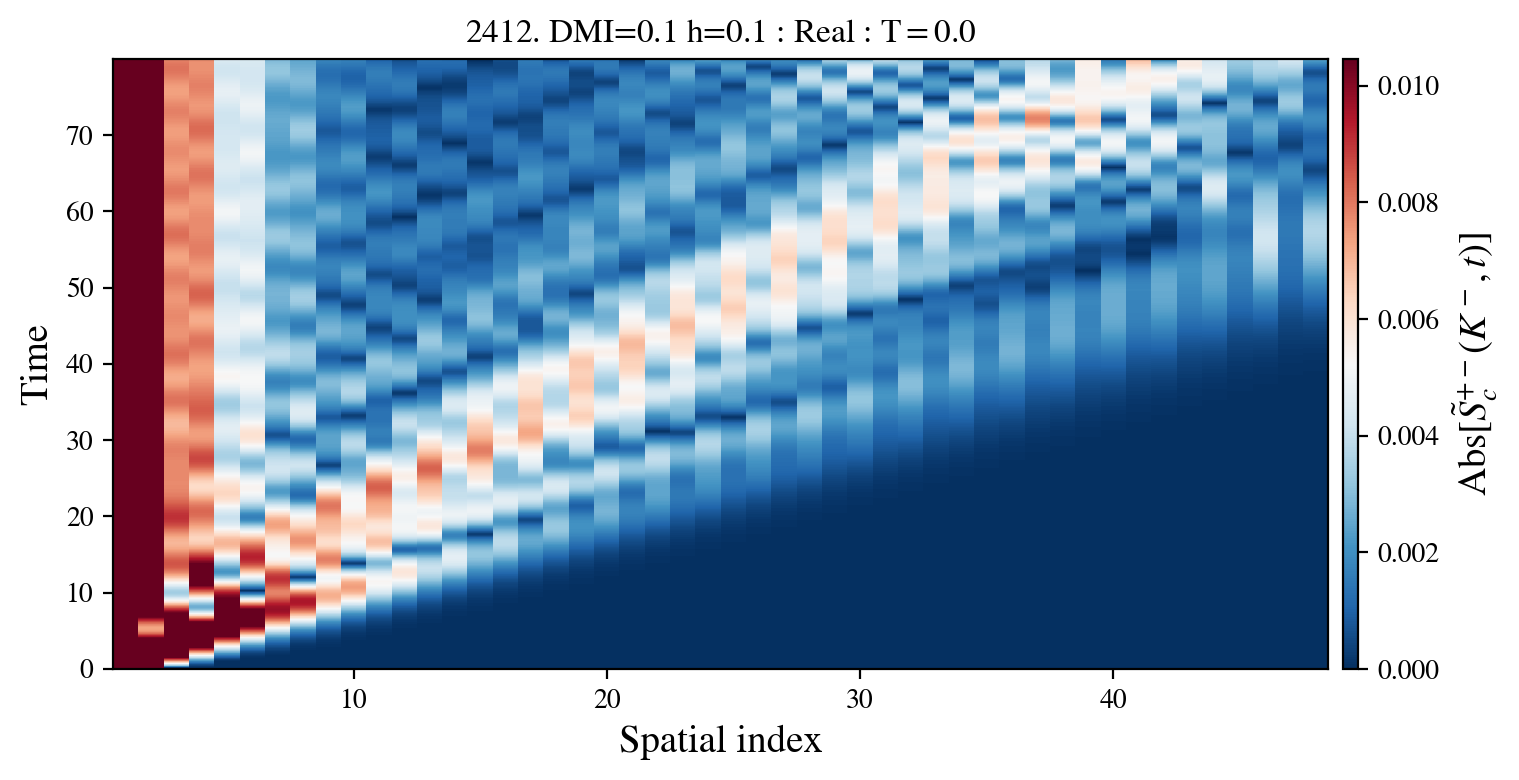

In [4]:
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
# fig, ax = plt.subplots(figsize=(6, 8), dpi=200)

# Extract RS/IS columns sorted by their numeric index
rs_cols = sorted([c for c in data.columns if c.startswith('RS')],
                    key=lambda c: int(c[2:]))
is_cols = sorted([c for c in data.columns if c.startswith('IS')],
                    key=lambda c: int(c[2:]))

chi_re = data[rs_cols].values[:T_max]  # shape: (n_time, n_space)
chi_im = data[is_cols].values[:T_max]
chi_abs = np.sqrt(chi_re**2 + chi_im**2)

time = data['t'].values[:T_max]
x = np.arange(1, len(rs_cols) + 1)  # spatial index

# --- extrapolate part ---
# spline = RectBivariateSpline(time, x, chi_abs, kx=3, ky=3)
# x = np.linspace(x.min(), x.max(), 10*len(x))
# chi_abs = spline(time, x)
# --- ---

vmax = np.abs(chi_abs).max()*0.5
im = ax.pcolormesh(x, time, chi_abs,
    cmap='RdBu_r', 
    vmin=0, vmax=vmax,
    # vmin=-vmax, vmax=vmax,
    # norm=colors.SymLogNorm(linthresh=0.002),
    shading='auto')
cbar = fig.colorbar(im, ax=ax, pad=0.01, aspect=40)
cbar.set_label(f'Abs[$\\tilde{{S}}^{{{operators}}}_c({K}, t)$]', fontsize=14)
# cbar.set_label('Re[$\\tilde{S}^{+-}_{c, x}(K^-, t)$]')

ax.set_xlabel('Spatial index', fontsize=14)
ax.set_ylabel('Time', fontsize=14)
ax.label_outer()
ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

# DSF

In [22]:
N = 6*4
M = N//2
beta = 0
nnn = 0.1
DM = 0.1
h = 0.1
AB = "1213"
ox, oy = 't', 'f'
operators = '+-'
gauge = 'real' # 'gauged'

if beta==0:
    files = sorted(glob.glob(f"../HC_data/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_h{h}*_Ox{ox}_Oy{oy}_AB{AB}_T0/Chi_*2.0*K-_*+-_{gauge}*.csv"))
else:
    files = glob.glob(f"../HC_data/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_h{h}*_Ox{ox}_Oy{oy}_AB{AB}_beta{beta}*/Chi_*_1.0*K-*{operators}_{gauge}.csv")
files

['../HC_data/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB1213_T0/Chi_2412_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB1213_scany_17_2.00K-_T0_psi-10_Time80_dt0.05_k4_+-_real_edgeflip4_qnf.csv']

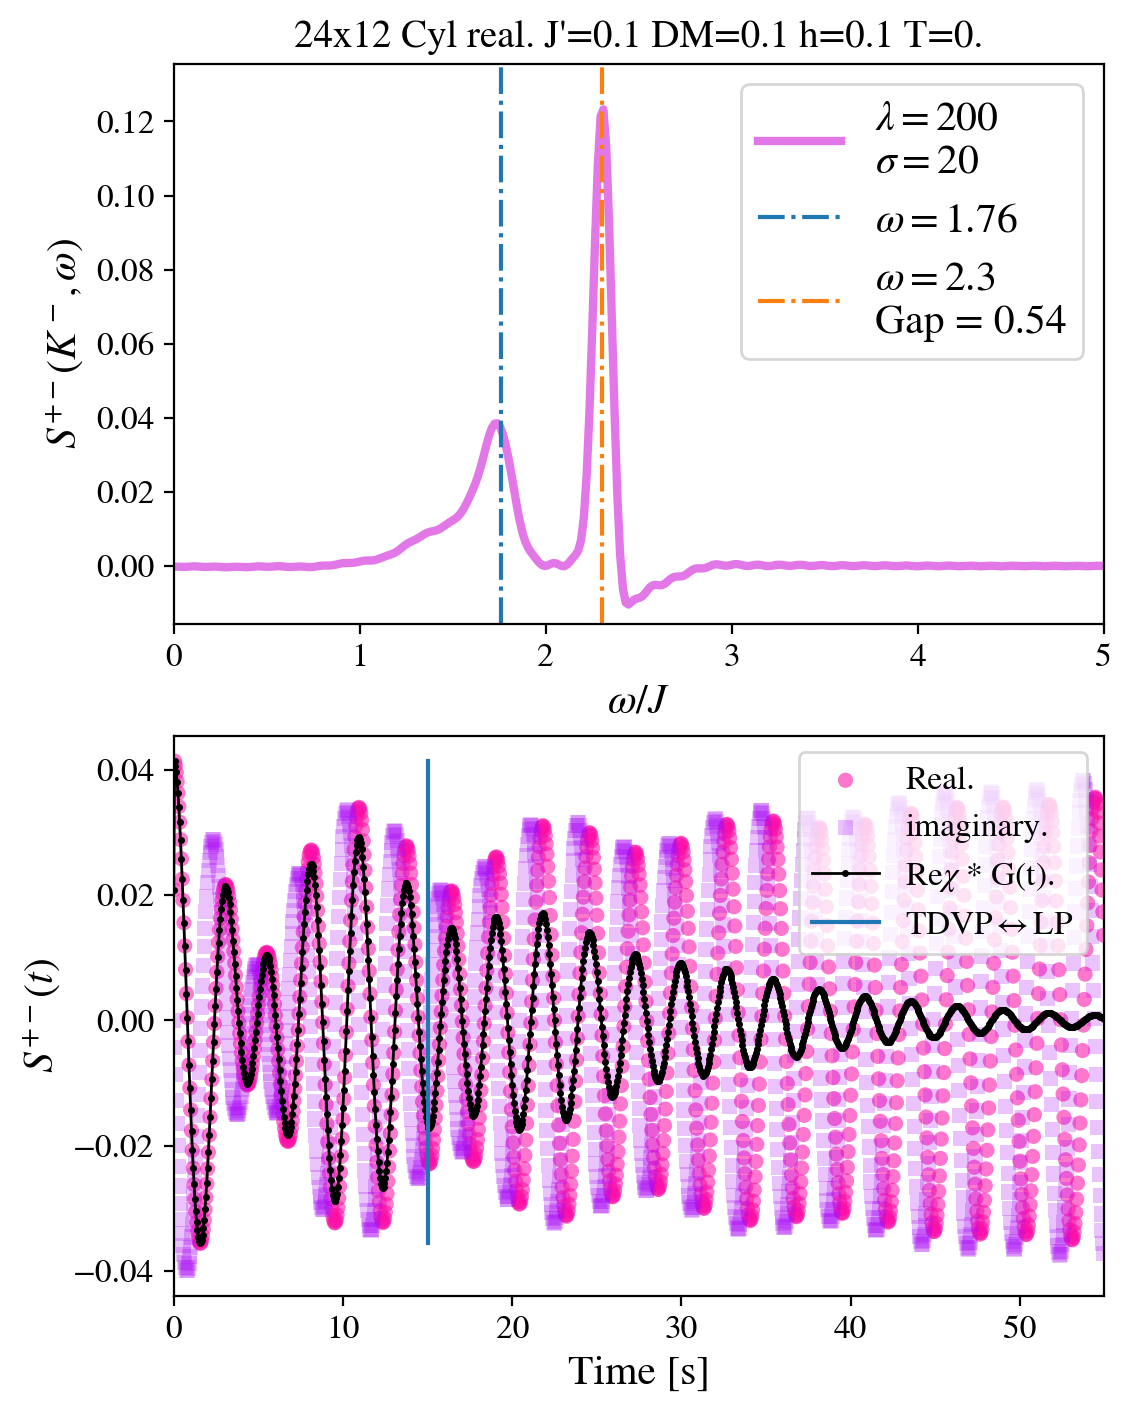

In [23]:
# p = 19*12+5 # points of extrapolation
p = 19*15
T_ex = 20*40
sigma = 20
dmrgT = 15

# beta = 0
T, c1, c2 = read_data(files[0], p, T_ex, col=0, cut=20*15)
S = DMRGplots(T, c1, c2, 1.76, 2.3, beta, sigma=sigma, 
    bc=f"Cyl {gauge}", operators=operators, Q="K^-", h=0.1, dmrgT=dmrgT, nomega=401)

(a1, a2)=(0.0109, 0.0112)
(c1, c2)=(2.32, 1.79)
Gamma=(0.135, 0.141)


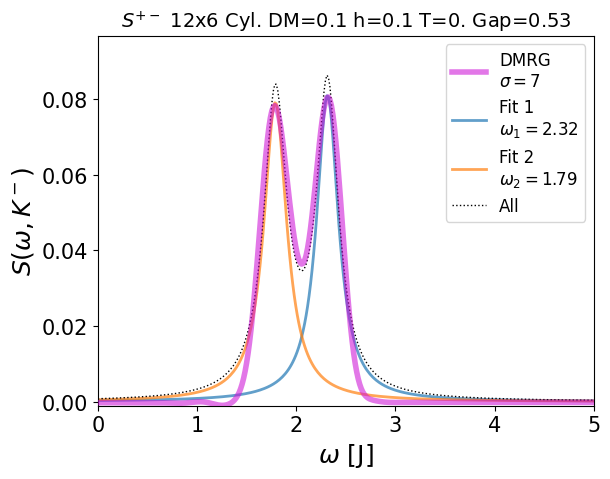

In [45]:
# p = [3.26, 2.67]
# Amp = [0.006, 0.009]
# w = [0.12, 0.15]
p = [2.35, 1.7]
Amp = [0.045, 0.035]
w = [0.2, 0.15]
fitplot(S, p, Amp, beta, bc="Cyl", Q="K^-", h=h, nomega=401, w=w, force=False)

# p = [2.32, 1.8, 1.]
# Amp = [0.013, 0.014, 0.002]
# w = [0.1, 0.2, 0.4]
# fitplot3(S, p, Amp, beta, bc="Cyl", Q="K^-", h=0.1, nomega=401, w=w)

# gap

In [24]:
T_dmrg = [0, 0.167, 0.25, 0.286, 0.303, 0.333, 0.37, 0.4]
dmrg_uband_pm = [2.33, 2.33, 2.34, 2.35, 2.36, 2.38, 2.39, 2.39]
dmrg_lband_pm = [1.79, 1.79, 1.78, 1.78, 1.78, 1.76, 1.73, 1.72]
gap_pm = [0.54, 0.54, 0.56, 0.57, 0.58, 0.62, 0.66, 0.67]


Temphp1, mgaphp1, band1p1, band2p1 = [], [], [], []
fnames = sorted(glob.glob('/home/amos1/edgestate/magnon/S0.5_nnn0.1_dmi0.1_h0.1/T*/bandfoo.test.txt'))
for fi in fnames:
    t = fi.split('/')[-2][1:]
    Temphp1.append(float(t))
    with open(fi, 'r') as f:
        lines = f.readlines()
        vals = lines[53].split()
        band1p1.append(float(vals[1]))
        band2p1.append(float(vals[2]))
        mgaphp1.append(float(vals[1]) - float(vals[2]))

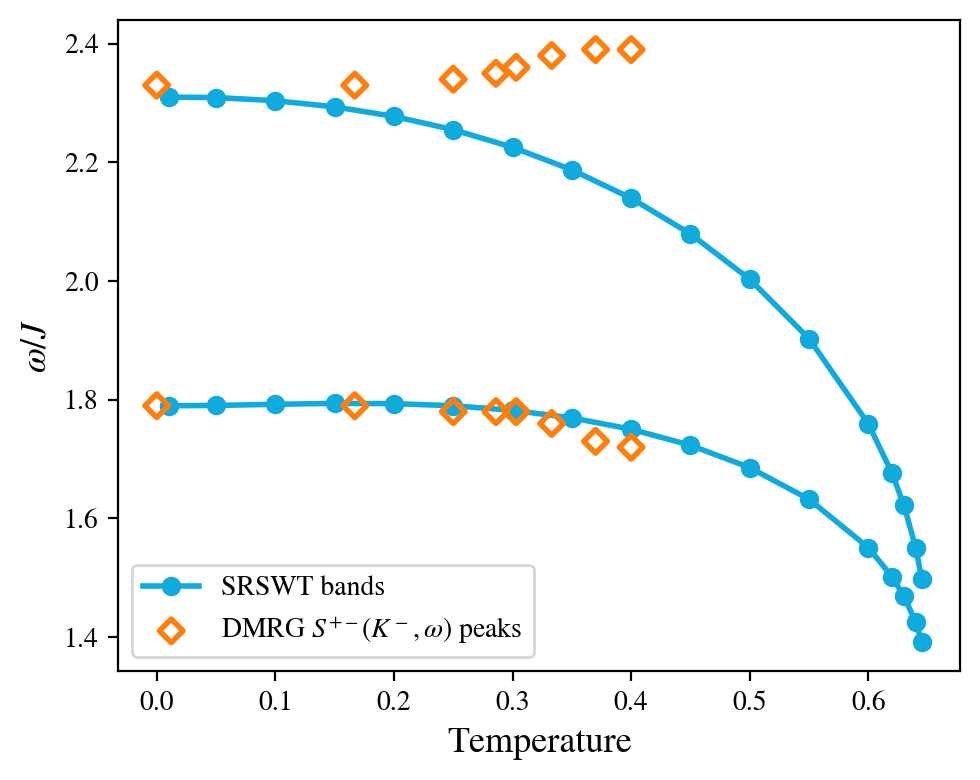

In [25]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

# ax = axs[0]
ax.plot(Temphp1[:-5], band1p1[:-5], marker='o', lw=2, c='#11AADD',
        label='SRSWT bands', zorder=1)
ax.plot(Temphp1[:-5], band2p1[:-5], marker='o', lw=2, c='#11AADD', zorder=1)
ax.scatter(T_dmrg, dmrg_uband_pm, marker='D', fc='none', ec='C1', linewidths=2, 
    label='DMRG $S^{+-}(K^-, \\omega)$ peaks')
ax.scatter(T_dmrg, dmrg_lband_pm, marker='D', fc='none', ec='C1', linewidths=2)

ax.legend(loc='lower left')
ax.set_ylabel('$\\omega/J$', fontsize=13)
ax.set_xlabel('Temperature', fontsize=13)
# ax.set_title('$K^-$ band')
ax.label_outer()

# ax = axs[1]
# ax.plot(Temphp1[:-5], mgaphp1[:-5], marker='o', lw=2, label='SRSWT gap', zorder=1)
# ax.scatter(T_dmrg, gap_pm, marker='D', c='C1', label='DMRG $S^{+-}$ gaps')
# ax.set_xlabel('Temperature')

# for ax in axs:
#     ax.legend(loc='lower left')
#     ax.set_ylabel('$\\omega/J$')

plt.tight_layout()
plt.show()

## Gap size

In [6]:
T_dmrg_hp1 = [0, 0.143, 0.2, 0.25, 0.303, 0.333, 0.357]
dmrg_band1p1 = [2.31, 2.32, 2.34, 2.38, 2.43, 2.42, 2.39]
dmrg_band2p1 = [1.79, 1.8, 1.81, 1.81, 1.76, 1.74, 1.72]
gaphp1 = [0.52, 0.52, 0.54, 0.57, 0.67, 0.68, 0.67]

T_dmrg_h1 = [0, 0.333, 0.5, 0.588, 0.667, 0.769]
dmrg_band11 = [3.21, 3.21, 3.22, 3.24, 3.26, 3.26]
dmrg_band21 = [2.69, 2.69, 2.68, 2.68, 2.69, 2.65]
gaph1 = [0.52, 0.52, 0.54, 0.56, 0.57, 0.61]

Temphp1, mgaphp1, band1p1, band2p1 = [], [], [], []
Temph1, mgaph1, band11, band21 = [], [], [], []
fnames = sorted(glob.glob('/home/amos1/edgestate/magnon/S0.5_nnn0.1_dmi0.1_h0.1/T*/bandfoo.test.txt'))
for fi in fnames:
    t = fi.split('/')[-2][1:]
    Temphp1.append(float(t))
    with open(fi, 'r') as f:
        lines = f.readlines()
        vals = lines[53].split()
        band1p1.append(float(vals[1]))
        band2p1.append(float(vals[2]))
        mgaphp1.append(float(vals[1]) - float(vals[2]))
fnames = sorted(glob.glob('/home/amos1/edgestate/magnon/S0.5_nnn0.1_dmi0.1_h1.0/T*/bandfoo.test.txt'))
for fi in fnames:
    t = fi.split('/')[-2][1:]
    Temph1.append(float(t))
    with open(fi, 'r') as f:
        lines = f.readlines()
        vals = lines[53].split()
        band11.append(float(vals[1]))
        band21.append(float(vals[2]))
        mgaph1.append(float(vals[1]) - float(vals[2]))


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 7), dpi=200)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'

ax = axs[0, 0]
ax.plot(Temphp1[:-5], band1p1[:-5], marker='o', lw=2, label='Magnon bands', zorder=1)
ax.plot(Temphp1[:-5], band2p1[:-5], marker='o', lw=2, c='C0', zorder=1)
ax.scatter(T_dmrg_hp1, dmrg_band1p1, marker='s', c='C1', label='DMRG bands')
ax.scatter(T_dmrg_hp1, dmrg_band2p1, marker='s', c='C1')
ax.set_title('h=0.1')
ax.set_ylabel('$\\omega$ [J]')

ax = axs[0, 1]
ax.plot(Temph1[:-5], band11[:-5], marker='o', lw=2, label='Magnon bands', zorder=1)
ax.plot(Temph1[:-5], band21[:-5], marker='o', lw=2, c='C0', zorder=1)
ax.scatter(T_dmrg_h1, dmrg_band11, marker='D', c='C1', label='DMRG bands')
ax.scatter(T_dmrg_h1, dmrg_band21, marker='D', c='C1')
ax.set_title('h=1.0')

ax = axs[1, 0]
ax.plot(Temphp1[:-5], mgaphp1[:-5], marker='o', lw=2, label='Magnon prediction')
ax.scatter(T_dmrg_hp1, gaphp1, marker='s', label='DMRG', c='C1')
ax.set_ylim(0, 0.75)
ax.set_ylabel('K$^{-}$ gap size [J]')

ax = axs[1, 1]
ax.plot(Temph1[:-5], mgaph1[:-5], marker='o', lw=2, label='Magnon prediction')
ax.scatter(T_dmrg_h1, gaph1, marker='D', label='DMRG', c='C1')
ax.set_ylim(0, 0.65)

for ax in axs.flatten():
    ax.legend(loc='lower left')
    # ax.label_outer()
    ax.set_xlabel('Temperature')

plt.tight_layout()
plt.show()

# $\chi_m$

In [22]:
fnames = sorted(glob.glob('../HC_data/*S0.5*'))
fnames

['../HC_data/126_S0.5_nnn0.10_DM0.00_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv',
 '../HC_data/126_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv',
 '../HC_data/126_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k300.csv',
 '../HC_data/126_S0.5_nnn0.10_DM0.30_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv',
 '../HC_data/189_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv']

## h0.1

In [23]:
Ns = [12, 12, 12, 12, 18]
Ms = [6, 6, 6, 6, 9]
labels = [
    '12x6 DM=0.0 k200', '12x6 DM=0.1 k200', '12x6 DM=0.1 k300', 
    '12x6 DM=0.3 k200', '18x9 DM=0.1 k200'
]

## plot

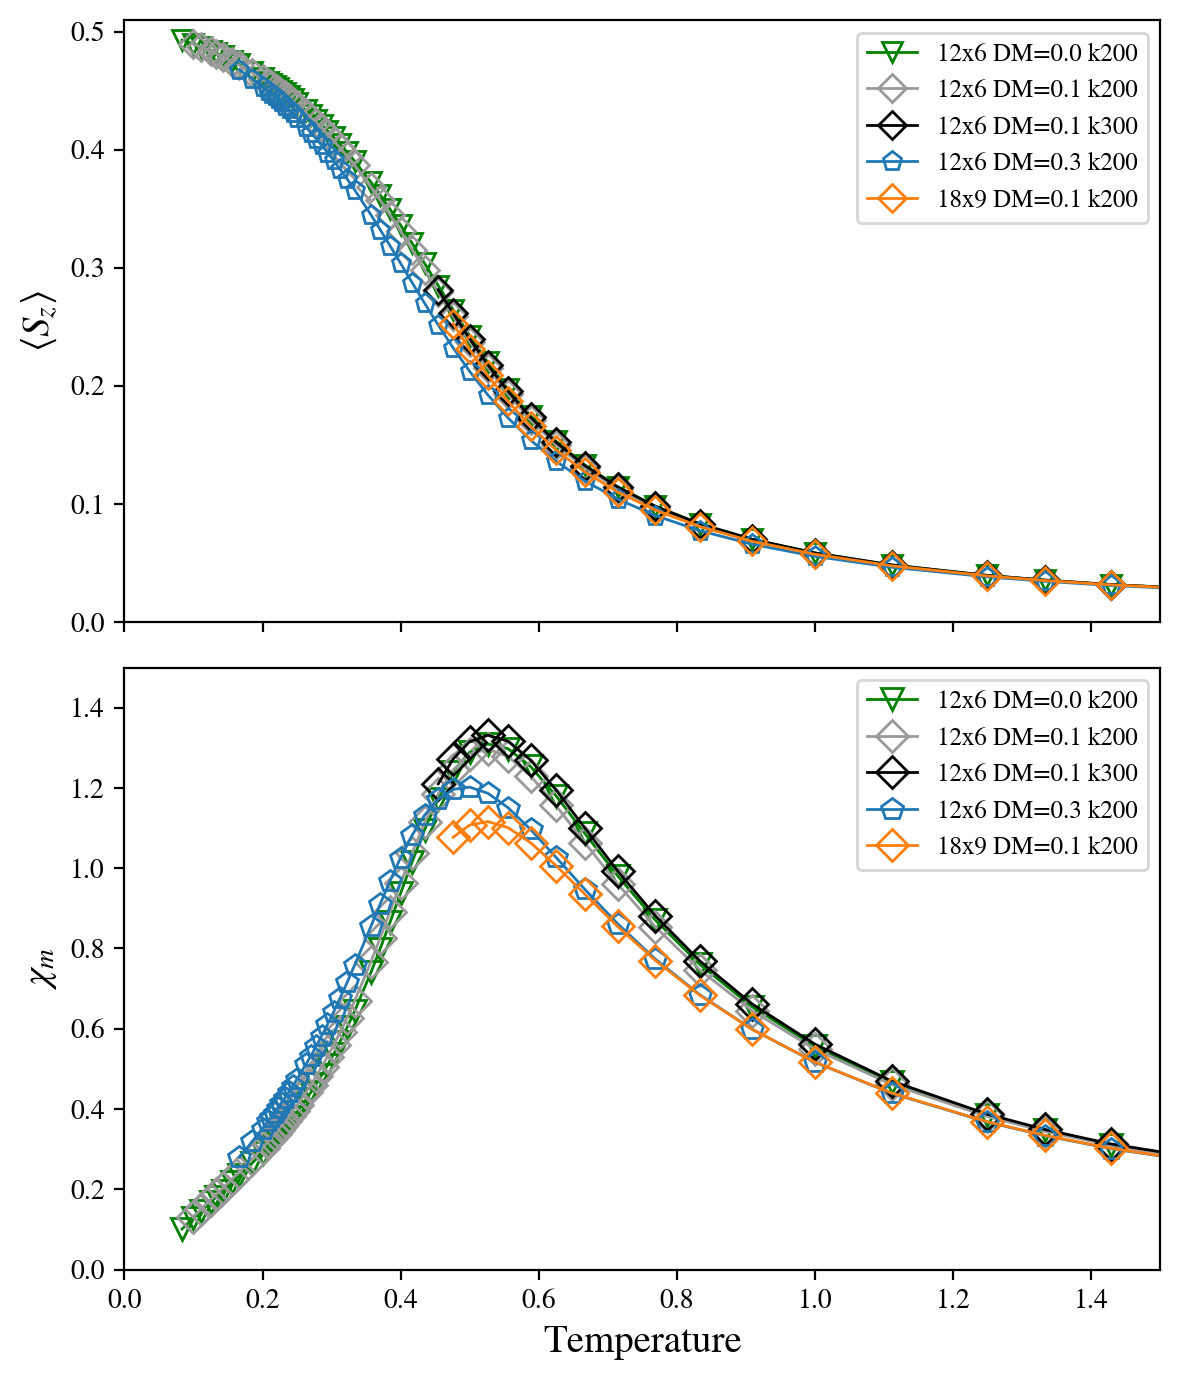

In [37]:
fig, axs = plt.subplots(2, 1, figsize=(6, 7), dpi=200)

mks = ['v', 'D', 'D', 'p', 'D', '^', '.', '.', '.', '.', '.']
# cs = ['#111111', '#333333', '#555555', '#777777', '#999999',
#     'k', 'C0', 'C1', 'C2', 'C3', 'C4']
cs = ['g', '#999999',
    'k', 'C0', 'C1', 'C2', 'C3', 'C4']

for i, fi in enumerate(fnames):
    N, M = Ns[i], Ms[i]
    
    factor = N*M*2

    data = pd.read_csv(fi)
    m_2 = data.Sz*data.Sz
    m2 = data.M2
    chi = data.beta * (m2 - m_2) * factor
    axs[0].plot(1/data.beta, data.Sz, 
        marker=mks[i], mfc='none', c=cs[i], label=labels[i], ms=7, lw=1)
    # axs[0].plot(1/data.beta, data.M2, alpha=0.5, 
    #     marker='D', mfc='none', color='k', mec='k', label=labels[i]+" $S_z^2$", ms=5, ls=":", lw=1)

    axs[1].plot(1/data.beta, chi,
        marker=mks[i], mfc='none', c=cs[i], label=labels[i], ms=8, lw=1)

x_range = 1.5
chi_range = [0, 1.5]

for ax in axs: 
    ax.legend(fontsize=9)
    ax.set_xlim(0, x_range)

axs[0].label_outer()
axs[0].set_ylim(0, 0.51)
axs[1].set_ylim(chi_range[0], chi_range[1])
axs[1].set_xlabel("Temperature", fontsize=14)
axs[1].set_ylabel("$\\chi_m$", fontsize=14)
axs[0].set_ylabel("$\\langle S_z \\rangle$", fontsize=14)

# axs[0].set_title('HC, Cyl. Jnnn=0.1, DM=0.1, h=0.1')
# axs[1].set_title('$\\chi_m = N\\beta[\\frac{1}{N^2}\\sum S_i^zS_j^z - (\\frac{1}{N}\\sum S_i^z)^2]$')
plt.tight_layout()
plt.show()

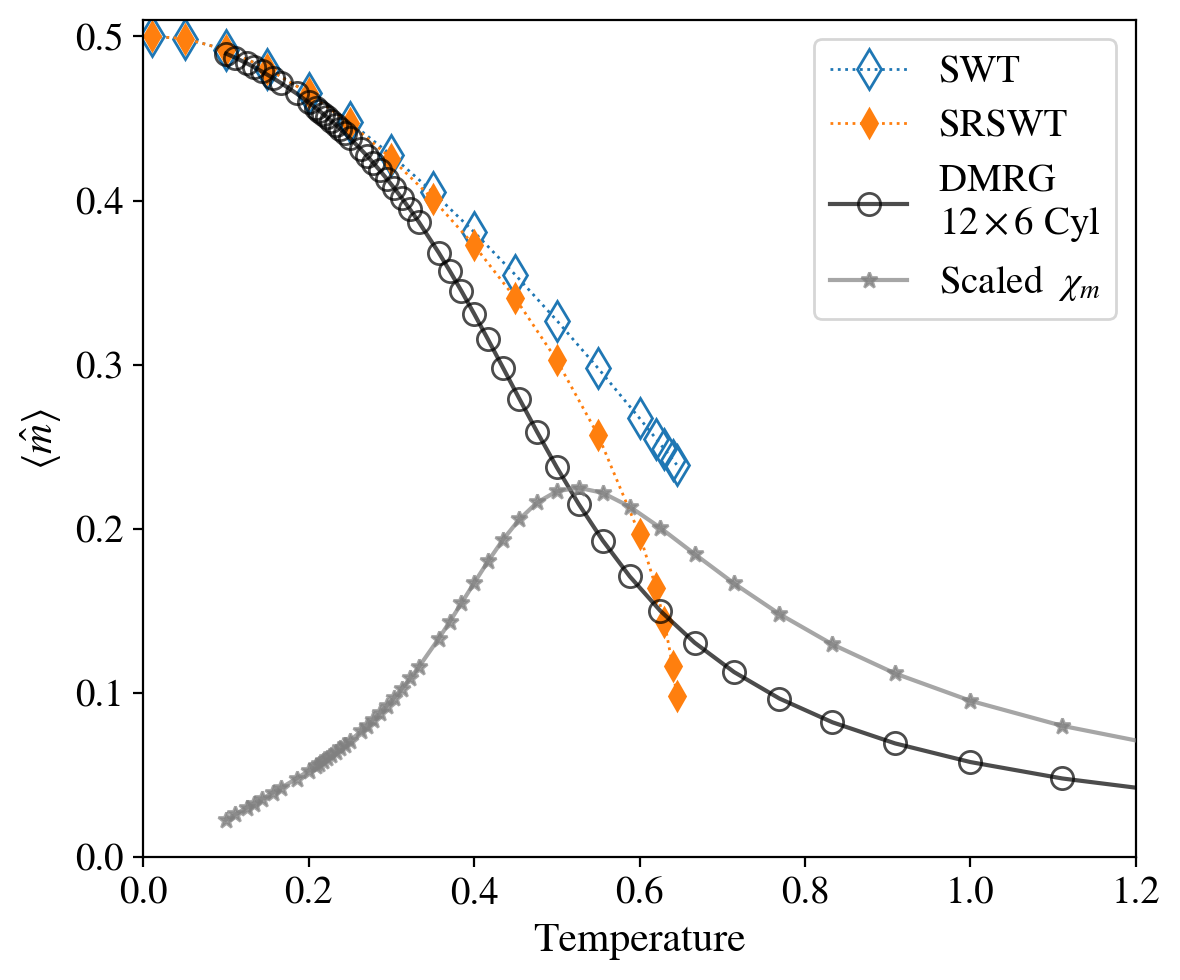

In [22]:
def plot_swt(ax, n):
    
    h='0.1'
    spin = '0.5'
    swt_files = sorted(glob.glob(f'/home/amos1/edgestate/magnon/S{spin}_nnn0.1_dmi0.1_h{h}/*/iterfoo*'))
    swt_O6_files = sorted(glob.glob(f'/home/amos1/edgestate/magnon/S{spin}_nnn0.1_dmi0.1_h{h}*_O6/*/iterfoo*'))

    T_list, Sz_0, Sz_sc = [], [], []
    for fi in swt_files:
        T_list.append(float(fi.split('/')[-2][1:]))
        with open(fi, 'r') as f:
            lines = f.readlines()
            vals = lines[0].split()
            Sz_0.append(float(vals[1]))
            vals = lines[-1].split()
            Sz_sc.append(float(vals[1]))
            
    ax.plot(T_list[:n], Sz_0[:n], 
        marker='d', mfc='none', color='C0', mec='C0', label='SWT', ms=10, lw=1, ls=':')
    ax.plot(T_list[:n], Sz_sc[:n], 
        marker='d', color='C1', mec='C1', label='SRSWT', ms=7, lw=1, ls=':')
    
def plot_chi(ax, data, label, scale, c='k'):
    m_2 = data.Sz*data.Sz
    m2 = data.M2
    chi = data.beta * (m2 - m_2)*scale
    ax.plot(1/data.beta, chi, zorder=7, alpha=0.7,
        marker='*', c=c, label=label)

fig, ax=plt.subplots(figsize=(6, 5), dpi=200)

n, m = 12, 6
dmrg = pd.read_csv(f'../HC_data/{n}{m}_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv')

labels = ['k300 cut0', 'k400 cut0', 'k400']
cs = ['C1', 'C2', 'C3', 'C4']
    
plot_swt(ax, 17)

ax.plot(1/dmrg.beta, dmrg.Sz, zorder=5, alpha=0.7,
    marker='o', ms=8, mfc='none', c='k', label='DMRG \n$12\\times6$ Cyl')

plot_chi(ax, dmrg, 'Scaled  $\\chi_m$', 25, c='grey')

ax.legend(fontsize=14)
ax.set_ylim(0, 0.51)
ax.set_xlim(0, 1.2)
ax.set_ylabel("$\\langle \\hat{m}\\rangle$", fontsize=15)
ax.set_xlabel('Temperature', fontsize=15)
ax.tick_params(labelsize=14)

# ax.set_title(f'{n}x{m} Cyl DM=0.1')
plt.tight_layout()
plt.show()

# DSF(t)

In [80]:
N, M = 12, 6
beta = '*'
nnn = 0.1
DM = 0.1
h = 0.1
operators = 'zz'
gauge = 'real'
AB = "*"
ox, oy = 't', 'f'

GSfile = sorted(glob.glob(f"../HC_data/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_h{h}*_Ox{ox}_Oy{oy}_AB{AB}_T0/Chi_*1.0*K-_*+-_{gauge}*.csv"))
print(GSfile[0])
files = sorted(glob.glob(f"../HC_data/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_h{h}*_Ox{ox}_Oy{oy}_AB{AB}_beta{beta}*/Chi_*_1.0*K-*{operators}_{gauge}.csv"))
# files = files[1:]
# files = files[:-1]
files

../HC_data/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB6667_T0/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB6667_scany_5_1.00K-_T0_psi-10_Time40_dt0.05_k4_+-_real_edgeflip4_qnf.csv


['../HC_data/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_beta3.30/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_5_1.00K-_beta3.30_tau-10_Time5_dt0.05_k200_zz_real.csv',
 '../HC_data/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_beta4.00/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_5_1.00K-_beta4.00_tau-10_Time5_dt0.05_k200_zz_real.csv',
 '../HC_data/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_beta5.00/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_5_1.00K-_beta5.00_tau-10_Time5_dt0.05_k200_zz_real.csv',
 '../HC_data/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_beta6.00/Chi_126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_AB132134_5_1.00K-_beta6.00_tau-10_Time5_dt0.05_k200_zz_real.csv']

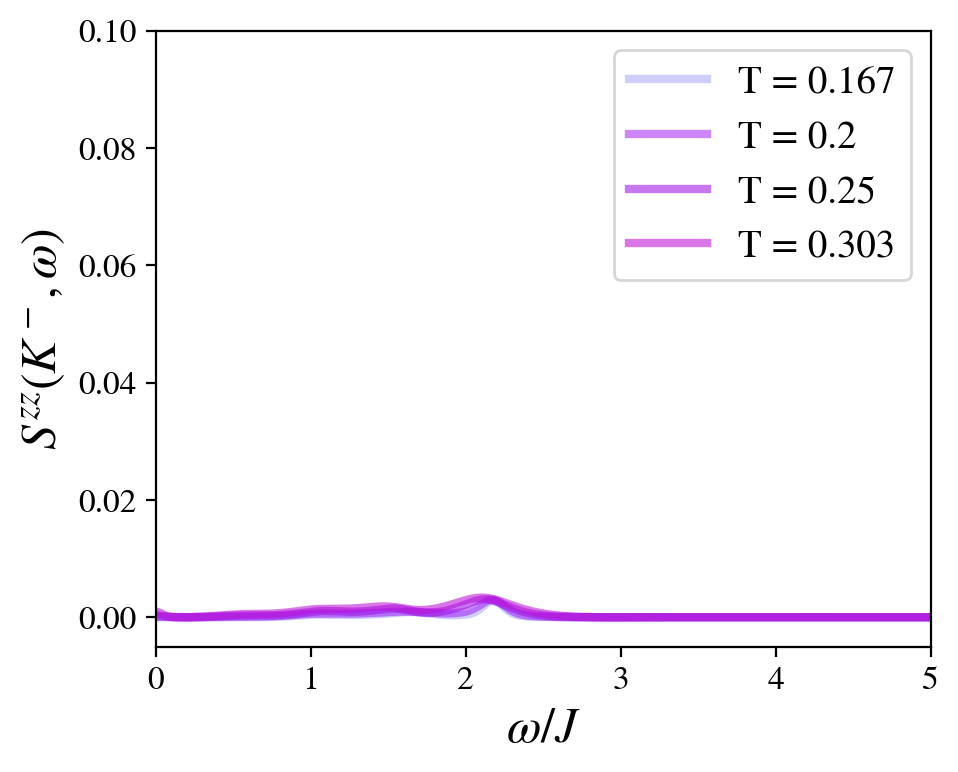

In [85]:
# Temp = [0.167, 0.25, 0.286, 0.303, 0.333, 0.37, 0.4]
Temp = [0.167, 0.2, 0.25, 0.303]
# Temp = [0.25, 0.27, 0.30, 0.33, 0.35, 0.4]
# Temp = [0.33, 0.5, 0.59, 0.67, 0.77, 0.9]
colors = ['#9C9FF680', '#9C0FF680', '#9C0FE690', '#BC0FD690', '#DC0FD690', '#FC0FD690', '#FC0FA690']
Q="K^-"
w = np.linspace(0, 6, 400)
ymin, ymax = -0.005, 0.1
# ymin, ymax = -0.005, 0.13
# ymin, ymax = -0.0001, 0.0035

# cuts = [20*10, -1, -1, -1, -1, -1, -1]
# sigmas = [10, 0, 0, 0, 0, 0, 0]
# ps = [19*10, 19*15, 19*15, 19*15, 19*15, 19*15, 19*15]
# T_ex = 20*40

cuts = [20*10, 20*10, -1, -1, -1, -1, -1]
sigmas = [20, 20, 0, 0, 0, 0, 0]
ps = [19*10+5, 19*10+5, 19*15, 19*15, 19*15, 19*15, 19*15]
T_ex = [20*40, 20*40, 20*35, 20*35]

def dsf(Time, chi_re, chi_im, sigma=0, c=1):
    gaussian = lambda x, sigma: np.exp(-(x/sigma)**2/2)

    dt = Time[1]-Time[0]
    sqT = 1/np.sqrt(2*Time[-1])
    Amp = gaussian(Time, sigma) if sigma > 0 else np.ones(len(Time))

    S = []
    for idx, omega in enumerate(w):
        int_sum = 0
        for i in range(len(Time)):
            int_sum += sqT * 2*np.cos(omega * Time[i]) * chi_re[i] * Amp[i]
            int_sum -= sqT * 2*np.sin(omega * Time[i]) * chi_im[i] * Amp[i]
        S.append(int_sum*dt/c)
    return S

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

# Time, chi_re, chi_im = read_data(GSfile[0], 19*10, 20*50, col=0, cut=20*10)
# # print(f'T0 time={Time[-1]}')
# ax.plot(w, dsf(Time, chi_re, chi_im, 10), 
#     lw=1, c='grey', 
#     label=f"T = 0", zorder=1)

for i, fi in enumerate(files[::-1]):
    Time, chi_re, chi_im = read_data(fi, ps[i], T_ex[i], col=0, cut=cuts[i])
    
    ax.plot(w, dsf(Time, chi_re, chi_im, sigmas[i]), 
        lw=3, c=colors[i], 
        label=f"T = {Temp[i]}")
    
    # ax.plot([p1[i], p1[i]], [ymin, ymax], label=f'$\\omega=${p1}', ls='-.')
    # ax.plot([p2[i], p2[i]], [ymin, ymax], label=f'$\\omega=${p2} \nGap = {round(p2-p1, 3)}', ls='-.')

ax.legend(fontsize=14, loc='upper right')
ax.set_xlabel("$\\omega/J$", fontsize=18)
ax.set_ylabel(f"$S^{{{operators}}}({Q}, \\omega)$", fontsize=18)
ax.set_xlim(0, 5)
ax.set_ylim(ymin, ymax)
ax.tick_params(axis='both', labelsize=12)

# ax.set_title(f"{N}$\\times${M} Cyl. J\'={nnn} DM={DM} h={h}", fontsize=14)

plt.show()

In [126]:
Time

array([0.000e+00, 5.000e-02, 1.000e-01, ..., 5.490e+01, 5.495e+01,
       5.500e+01], shape=(1101,))

# SC

In [46]:
# N = 12
# M = N//2
N, M = 2, 2
# fnames = sorted(glob.glob(f'../HC_data/{N}{M}_S0.5*'))
fnames = sorted(glob.glob(f'../HC_data/{N}{M}_*DM0.1*xtrg*'))
# data = pd.read_csv(fnames[-1])
fnames

['../HC_data/22_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0006_m15_k256_cut0_xtrg_ty8.csv',
 '../HC_data/22_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0007_m14_k256_cut0_xtrg_ty8.csv',
 '../HC_data/22_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0008_m13_k256_cut0_xtrg_ty8.csv',
 '../HC_data/22_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0009_m15_k256_cut0_xtrg_ty8.csv',
 '../HC_data/22_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k256_cut0_xtrg_ty8.csv']

In [47]:
data = pd.read_csv(fnames[0])
for i in range(len(fnames)-1):
    add_data = pd.read_csv(fnames[i+1])
    data = pd.concat([data, add_data], ignore_index=True)

data = data.sort_values(by='beta')

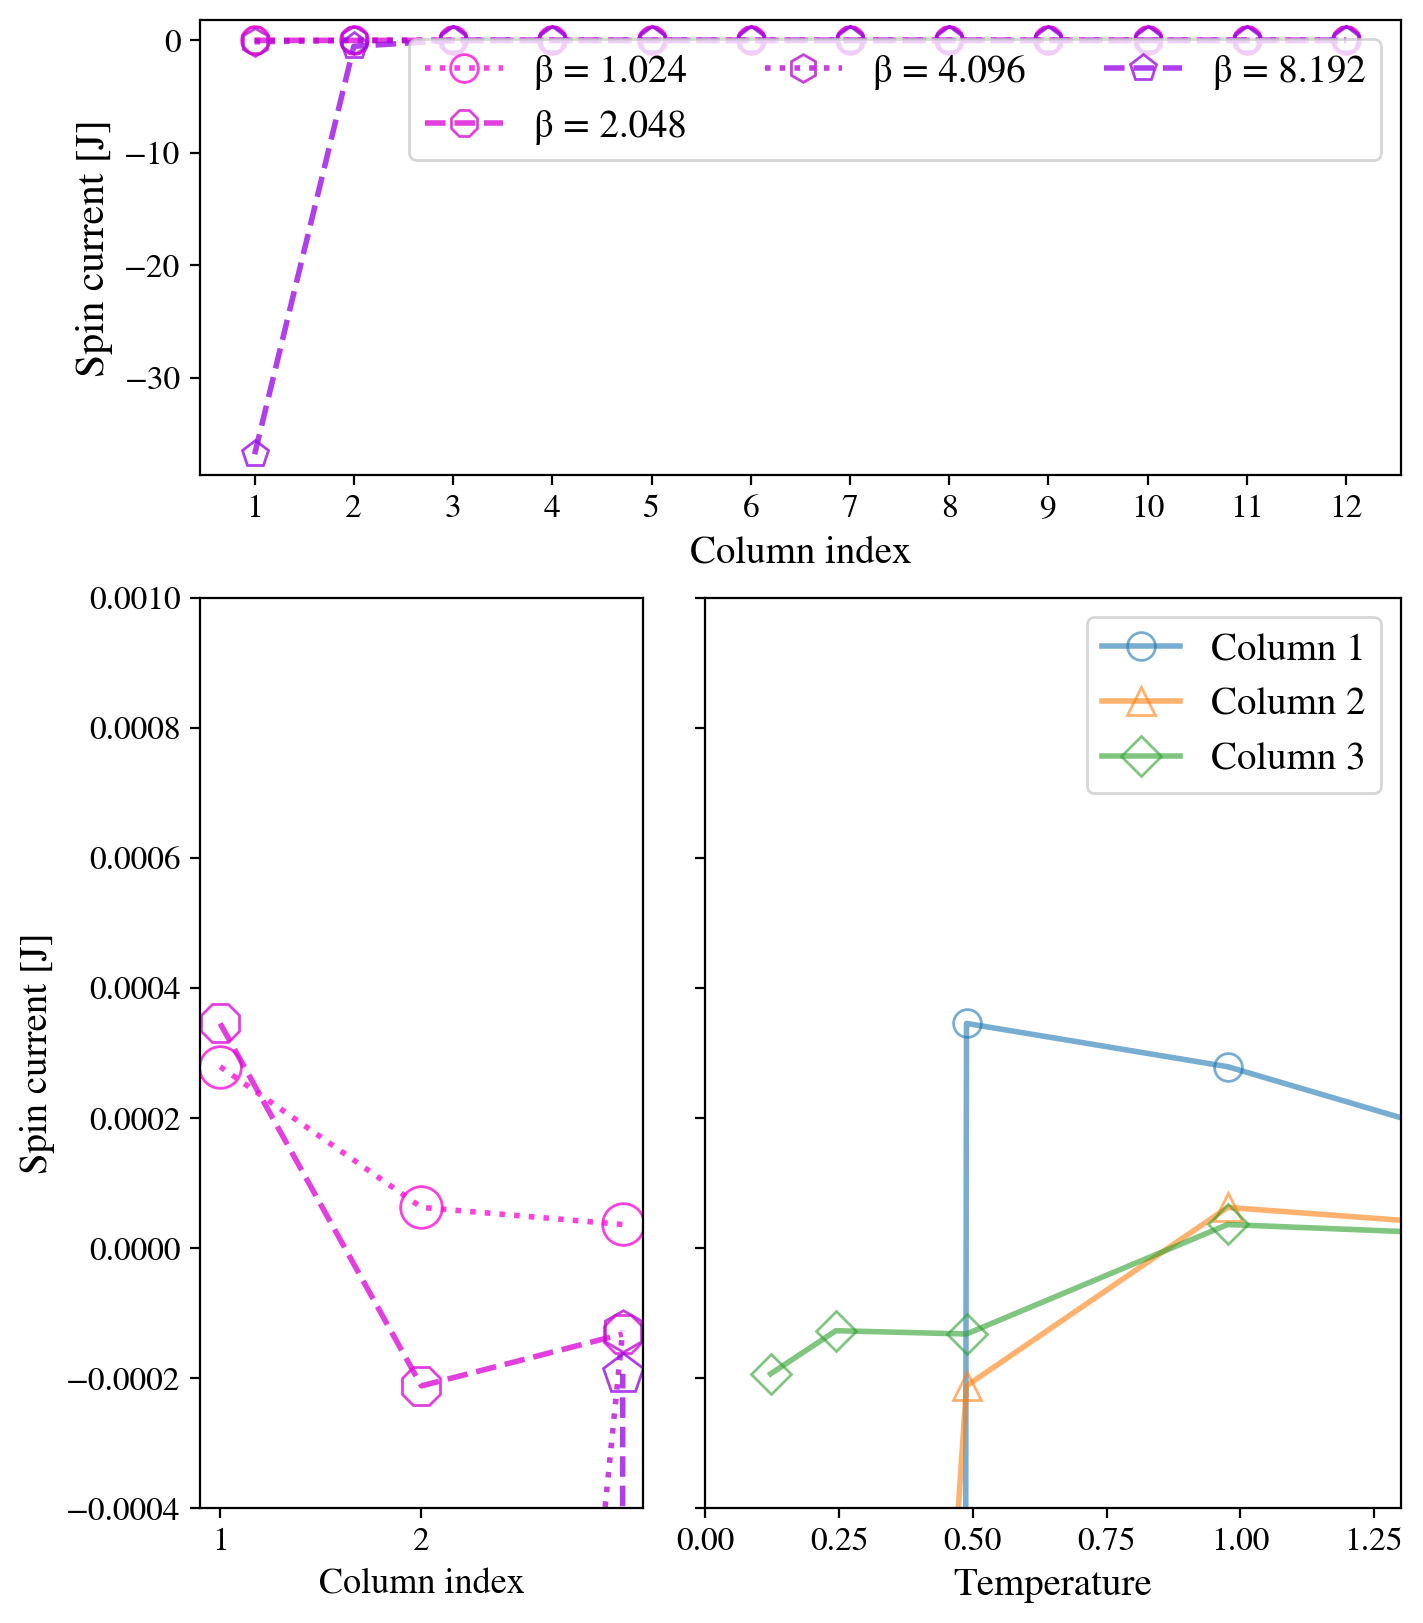

In [41]:
beta = [1.024, 2.048, 4.096, 8.192]
# beta = [1.5, 2.1, 2.3, 2.5, 4, 7]
# beta = [1, 1.2, 1.4, 1.5, 1.7, 2]
sc = lambda i, j: f"S+{i} S-{j}"
# sc = lambda i, j: f"S+{2*i} S-{2*j}"
DMI = 0.1

lws = [3, 3, 3, 2, 2, 2, 2]
lss = ['-', '-', '-', '--', ':', '--', ':']
markers = ['*', '^', 's', 'p', 'h', '8', 'o']
colors = ['#7C7F96', '#9C9FF680', '#9C0FF680', '#9C0FE690', '#BC0FD690', '#DC0FD690', '#FC0FD690']
ylims = [-0.0004, 0.001]

from matplotlib.gridspec import GridSpec

fig = plt.figure(layout="constrained", figsize=(7, 8), dpi=200)

gs = GridSpec(3, 5, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1:, :2])
ax3 = fig.add_subplot(gs[1:, 2:])

#  ax1
ax = ax1
for j, b in enumerate(beta):
    if b in data.beta.values:
        
        spincurrent = []
        for i in range(N):
            A, B = M+i*2*M, M+2+i*2*M
            spincurrent.append(2*DMI*(data[sc(A, B)].loc[data.beta==b] - data[sc(A+1, B-3)].loc[data.beta==b]))
    
        ax.plot(np.arange(1, N+1), spincurrent, lw=lws[::-1][j], ls=lss[::-1][j],
            alpha=0.8, marker=markers[::-1][j], c=colors[::-1][j],
            markersize = 10, markerfacecolor='none',
            label=f"β = {b}"
            )
    
ax.legend(fontsize=14, loc='upper right', ncol=3)
# ax.set_ylim(-0.0025, 0.0125)
ax.set_xticks(np.arange(1, N+1))
ax.set_xlabel('Column index', fontsize=14)
ax.set_ylabel('Spin current [J]', fontsize=15)
ax.tick_params(axis='both', labelsize=12)

# ax2
ax = ax2
for j, b in enumerate(beta):
    if b in data.beta.values:
        
        spincurrent = []
        for i in range(3):
            A, B = M+i*2*M, M+2+i*2*M
            spincurrent.append(2*DMI*(data[sc(A, B)].loc[data.beta==b] - data[sc(A+1, B-3)].loc[data.beta==b]))
    
        ax.plot([1, 2, 3], spincurrent, lw=lws[::-1][j], ls=lss[::-1][j],
            alpha=0.8, marker=markers[::-1][j], c=colors[::-1][j],
            markersize = 15, markerfacecolor='none',
            label=f"β = {b}"
            )

# ax.legend(fontsize=14, loc='upper right')
ax.set_xticks([1, 2])
ax.set_ylim(ylims)
ax.set_xlabel('Column index', fontsize=13)
ax.set_ylabel('Spin current [J]', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# ax3
ax = ax3

markers = ['o', '^', 'D', 'D', 'v', '8']
colors = ['C0', 'C1', 'C2', 'C2', 'C1', 'C0']
columns = [1, 2, 3]
for i, c in enumerate(columns):
    
    A, B = M+(c-1)*2*M, M+2+(c-1)*2*M
    spincurrent = 2*DMI*(data[sc(A, B)] - data[sc(A+1, B-3)])
        
    ax.plot(1/data.beta, spincurrent, lw=2,
        alpha=0.6, marker=markers[i], c=colors[i],
        markersize = 10, markerfacecolor='none',
        label=f"Column {c}")

ax.legend(loc='upper right', fontsize=14)
ax.label_outer()
ax.set_xlim(0, 1.3)
ax.set_ylim(ylims)
ax.set_xlabel('Temperature', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# plt.tight_layout()
plt.show()

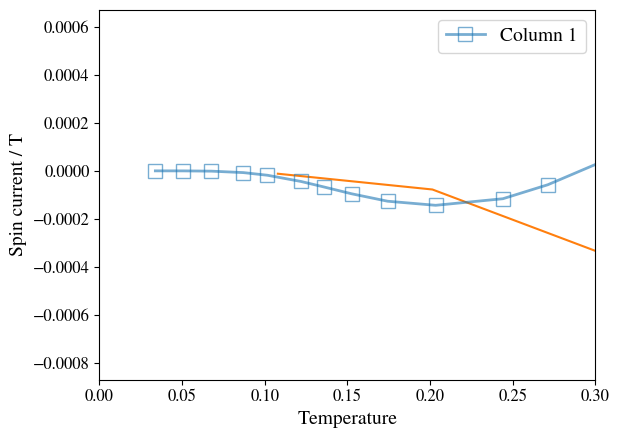

In [50]:
fig, ax=plt.subplots()

sc = lambda i, j: f"S+{i} S-{j}"

c = 1
DMI = 0.1
A, B = M+(c-1)*2*M, M+2+(c-1)*2*M
spincurrent = 2*DMI*(data[sc(A, B)] - data[sc(A+1, B-3)])

T = np.array([0.10799, 0.2015, 0.3012, 0.40083, 0.5007])
kappa = np.array([ -0.001198, -0.007762, -0.03359, -0.0630, -0.079851])
ax.plot(T, 0.01*kappa, c='C1')
    
ax.plot(1/data.beta, spincurrent , lw=2,
    alpha=0.6, marker='s', c='C0',
    markersize = 10, markerfacecolor='none',
    label=f"Column {c}")

ax.legend(loc='upper right', fontsize=14)
ax.set_xlim(0, 0.3)
# ax.set_ylim(-0.002, 0)
ax.set_xlabel('Temperature', fontsize=14)
ax.set_ylabel('Spin current / T', fontsize=14)
ax.tick_params(axis='both', labelsize=12)